In [1]:
import matplotlib.pyplot as plt
import scienceplots

plt.style.use('science')

import numpy as np
from scipy.optimize import bisect

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

from pycbc.psd.analytical import aLIGO140MpcT1800545, aLIGO175MpcT1800545
from pycbc.filter import sigma, sigmasq
from pycbc.types import TimeSeries, FrequencySeries

PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


In [2]:
import sys
import os

sys.path.insert(1, '../../detectability')

import resonance
from resonance import Filter, phase_diff_t_shift, phase_shift #System, 

In [3]:
data_phi_path = '../data/III/snr/phi'
os.makedirs(data_phi_path, exist_ok=True) 
figures_phi_path = '../figures/III/snr/phi'
os.makedirs(figures_phi_path, exist_ok=True) 

data_t_path = '../data/III/snr/t'
os.makedirs(data_t_path, exist_ok=True) 
figures_t_path = '../figures/III/snr/t'
os.makedirs(figures_t_path, exist_ok=True) 

figures_compare_path = '../figures/III/snr/compare'
os.makedirs(figures_compare_path, exist_ok=True) 

# Detectability

In [4]:
def detectability_plot(detector, dPsi):
    data = np.load(os.path.join(f'../data/III/snr/{x_type[dPsi]}', f'{x_type[dPsi]}_{detector_name[detector]}.npz'))
    fres_arr = data['fres']
    dx_arr = -data['detect']
    dx_guess_arr = -data['guess']
    joc_arr = -data['joc']
    joc_arr[np.isnan(joc_arr)] = 0
    dx_cut_arr = -data['cut']

    plt.figure(figsize=(6, 4))
    plt.loglog(fres_arr, dx_arr, '+', label='Exact')
    plt.loglog(fres_arr, dx_guess_arr, label='Guess')
    #plt.loglog(fres_arr, dx_cut_arr,'k', alpha=0.5, label='Cut')
    joc=FrequencySeries(joc_arr, delta_f=1.)

    if dPsi == phase_shift:
        plt.loglog(joc.sample_frequencies, joc, label='J. Read 2023') #Detectability lower bound
        plt.title(f'Detectable phase shift at $SNR=100$. {detector_name[detector]}')
        plt.ylabel('- Phase shift [rad]')
        plt.xlabel('Resonant Frequency [Hz]')
        plt.legend()

    elif dPsi == phase_diff_t_shift:
        plt.loglog(joc.sample_frequencies, joc/(2*np.pi*joc.sample_frequencies), label='J. Read 2023 approximation') #Detectability lower bound
        plt.title(f'Detectable time shift at $SNR=100$. {detector_name[detector]}')
        plt.ylabel('- Time shift [s]') 
        plt.xlabel('Resonant Frequency [Hz]')
        plt.legend()
    
    #plt.xlim(fres_arr[0],fres_arr[-1])
    plt.xlim(15,600)
    plt.savefig(os.path.join(f'../figures/III/snr/{x_type[dPsi]}', f'{x_type[dPsi]}_{detector_name[detector]}.png'), bbox_inches='tight')

    plt.show()

In [5]:
detector_name = {aLIGO175MpcT1800545: 'O4', 'aLIGO/AplusDesign': 'Aplus', 'aLIGO/Asharp_strain': 'Asharp', 'ET/ET_B': 'ET','CE/CE_40': 'CE'} 
x_type = {phase_shift: 'phi', phase_diff_t_shift: 't'}

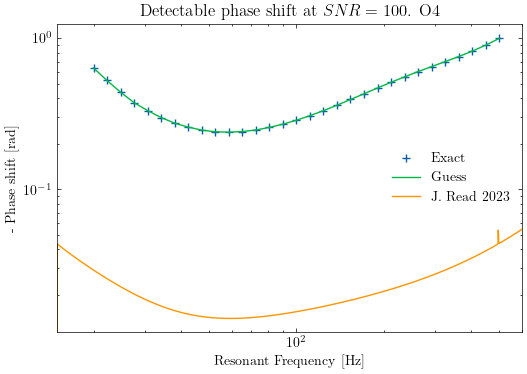

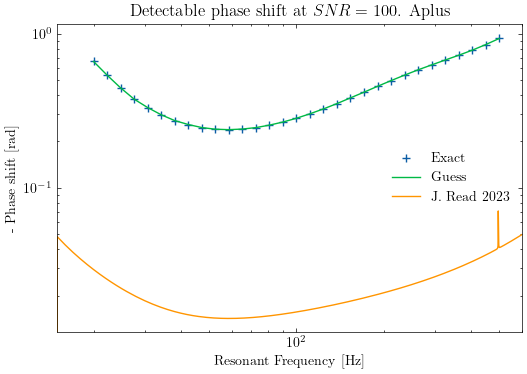

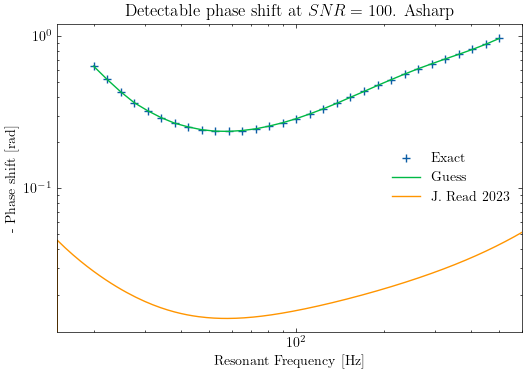

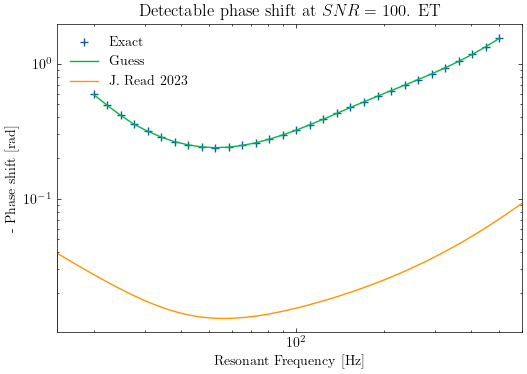

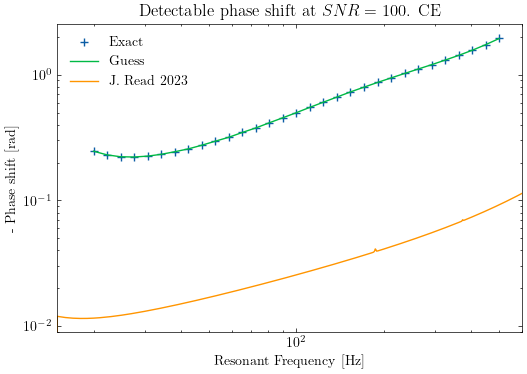

/home/alberto/ns-resonance/jupyter-env/lib/python3.12/site-packages/pycbc/types/array.py:383: RuntimeWarning: invalid value encountered in divide
  return self._data / other


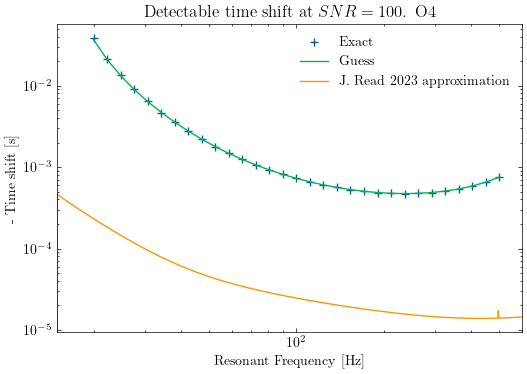

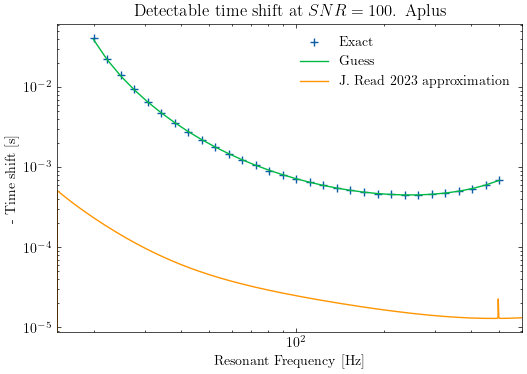

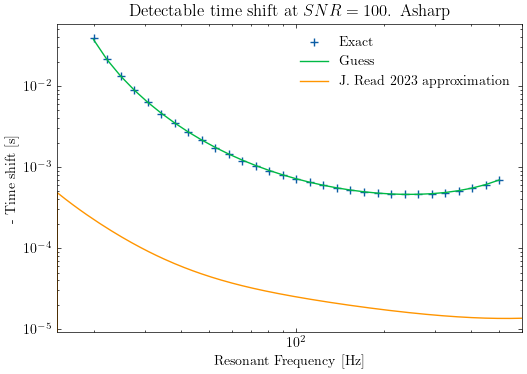

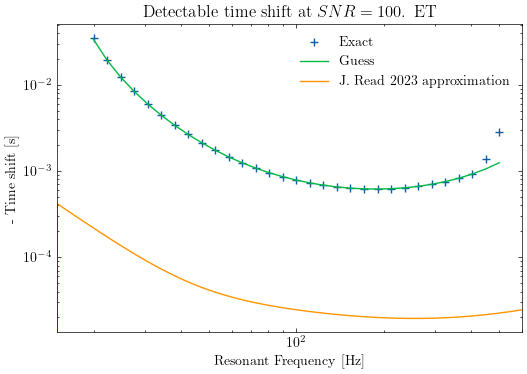

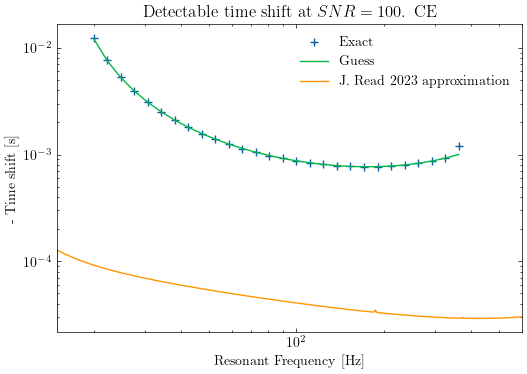

[None, None, None, None, None]

In [6]:
detector_list = [aLIGO175MpcT1800545, 'aLIGO/AplusDesign', 'aLIGO/Asharp_strain', 'ET/ET_B', 'CE/CE_40']
[detectability_plot(detector, phase_shift) for detector in detector_list]

[detectability_plot(detector, phase_diff_t_shift) for detector in detector_list]

In [7]:
def compare_plot(dx_detector):
    plt.figure(figsize=(6, 4))
    for detector, color in dx_detector:
        data_t = np.load(os.path.join('../data/III/snr/t', f't_{detector_name[detector]}.npz'))
        data_phi = np.load(os.path.join('../data/III/snr/phi', f'phi_{detector_name[detector]}.npz'))
                  
        fres_t_arr = data_t['fres']
        t_arr = -data_t['detect']
    
        fres_phi_arr = data_phi['fres']
        phi_arr = -data_phi['detect']
    
        plt.loglog(fres_t_arr, t_arr*1e3, '+', color=color, label=f'Time Shift. {detector_name[detector]}')
        plt.loglog(fres_phi_arr, phi_arr *1e3/(2*np.pi*fres_phi_arr), 'x', color=color, label=f'Converted Phase Shift. {detector_name[detector]}')
        #/(2*np.pi*fres_phi_arr)
    plt.title(f'Compare time and phase shifts at $SNR=100$')
    plt.xlabel('Frequency [Hz]')
    plt.ylabel(f'- Time shift [ms]')
    plt.legend()
    plt.savefig(os.path.join(f'../figures/III/snr/compare', f'compare.png'), bbox_inches='tight')
    
    plt.show()

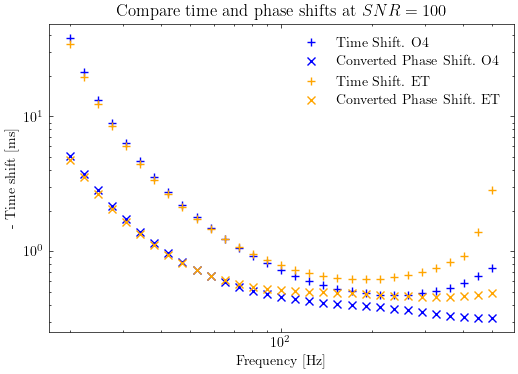

In [8]:
dx_detector = [[aLIGO175MpcT1800545, 'blue'], ['ET/ET_B', 'orange']]
#dx_detector = [[dt_O4[0], dphi_O4[0], 'O4', 'red'], [dt_Aplus[0], dphi_Aplus[0], 'Aplus', 'blue'], [dt_Asharp[0], dphi_Asharp[0], 'Asharp', 'green'], [dt_ET[0], dphi_ET[0], 'ET', 'orange'], [dt_CE[0], dphi_CE[0], 'CE', 'k']]

compare_plot(dx_detector)

In [9]:
def article_plot(dx_detector, dPsi):
    if dPsi == phase_shift:
        x = 'phi'
    elif dPsi == phase_diff_t_shift:
        x = 't'

    plt.figure(figsize=(6, 4))
    for detector, color in dx_detector:
        data = np.load(os.path.join(f'../data/III/snr/{x}', f'{x}_{detector_name[detector]}.npz'))
                  
        fres_arr = data['fres']
        dx_arr = -data['detect']
        dx_guess_arr = -data['guess']
        joc_arr = -data['joc']
        dx_cut_arr = -data['cut']

    
        plt.loglog(fres_arr, dx_arr, '+', color = color, label=f'Exact. {detector_name[detector]}')
        plt.loglog(fres_arr, dx_guess_arr, 'x', color = color, label=f'Guess. {detector_name[detector]}')
        #plt.loglog(fres_arr, dx_cut_arr, color = color, alpha=0.5, label=f'Cut. {detector_name[detector]}')
        
        joc=FrequencySeries(joc_arr, delta_f=1.)
        
        if dPsi == phase_shift:
            plt.loglog(joc.sample_frequencies, joc, '-.', color = color, label=f'J. Read 2023. {detector_name[detector]}') #Detectability lower bound
            plt.title(f'Detectable phase shift at $SNR = 100$')
            plt.ylabel('Phase shift [rad]')
            plt.xlabel('Resonant Frequency [Hz]')
            plt.legend(loc='best')
            plt.ylim(1e-2,11)
    
        elif dPsi == phase_diff_t_shift:
            plt.loglog(joc.sample_frequencies, joc/(2*np.pi*joc.sample_frequencies), '-.', color = color, label=f'J. Read 2023. {detector_name[detector]}') #Detectability lower bound
            plt.title(f'Detectable time shift at $SNR = 100$')
            plt.ylabel('Time shift [s]') 
            plt.xlabel('Resonant Frequency [Hz]')
            plt.legend(loc='best')

    plt.savefig(os.path.join(f'../figures/III/snr', f'{x}_article.png'), bbox_inches='tight')
    plt.show()

In [10]:
dx_detector = [[aLIGO175MpcT1800545, 'blue'], ['ET/ET_B', 'orange']]

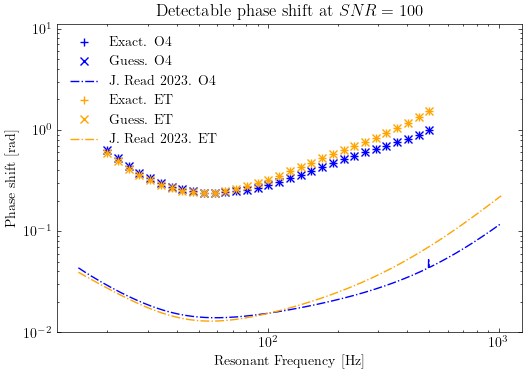

In [11]:
article_plot(dx_detector, phase_shift) 

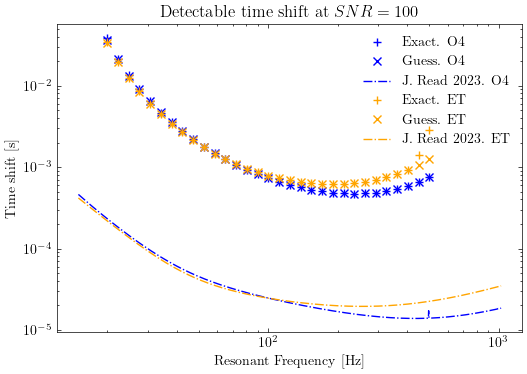

In [12]:
article_plot(dx_detector, phase_diff_t_shift) 